# 19 — waw on pyscf: Gaussian orbitals, and both LKAG formulations side by side

The third localized-basis door into waw, after Wannierization of plane waves
(notebooks 1–17) and SIESTA's numerical atomic orbitals (notebook 18).
A periodic **pyscf** mean-field hands over the Fock matrix $F(k)$ and the
overlap $S(k)$ in a **Gaussian AO** basis — localized but non-orthogonal, the
same situation as SIESTA — so `waw.interfaces.pyscf` applies the same Löwdin
step, $H_\perp(k) = S^{-1/2} F S^{-1/2}$, and Fourier-transforms onto the
mesh's Wigner–Seitz $R$-set to produce a standard waw `HamiltonianR`.

Two things make the pyscf route the *pleasant* one:

* **No unit or reference traps.** pyscf works in Hartree/Bohr natively, so
  nothing is converted; and unlike SIESTA's HSX file (which stores
  $H - E_F S$, notebook 18's trap) the Fock matrix shares the absolute
  reference of `mo_energy`, with $E_F$ taken straight from the smearing
  chemical potential.
* **Both exchange formulations on identical data.** Because pyscf gives us
  $F$ *and* $S$, we can run LKAG **both** ways here — Löwdin-orthogonalized
  ($G = (z - H_\perp)^{-1}$) and genuinely non-orthogonal
  ($G = (zS - F)^{-1}$) — on the same matrices, same $E_F$, same mesh, same
  $R$-list. Notebook 18 could only compare across *codes* (waw's Löwdin vs
  TB2J's non-orthogonal `siesta2J`), where the formulation difference was
  entangled with a different Fermi-level convention. Here it is isolated.

What carries over unchanged is everything that needs only $H(\mathbf R)$:
bands, DOS, Fermi surfaces, surface Green functions, `analysis.exchange`,
`analysis.magnon`. What does not: the Berry-curvature class (AHC/SHC/orbital
moments/SAC) needs position matrix elements — pyscf *can* provide
`int1e_r`, so this door is openable, but it is deliberately not wired up yet
rather than silently approximated.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
waw.set_num_threads(16)
from scipy.linalg import eigh as geigh
from ase.build import bulk
from waw.interfaces.pyscf import lowdin_hamiltonian_pyscf
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.analysis.exchange import heisenberg_exchange, heisenberg_exchange_nonortho
from waw.analysis.magnon import magnon_bands
from waw.units import HARTREE_TO_EV

W = REPO / 'workflows' / 'notebooks' / 'runs' / 'fe_pyscf'
NK = 6 if (W / 'fe_6.npz').exists() else 4      # prefer the denser cache
CACHE = W / f'fe_{NK}.npz'
print(f'using the {NK}^3 cache: {CACHE.name}')

using the 6^3 cache: fe_6.npz


### 1. The periodic mean field

bcc Fe with a GTH-PBE pseudopotential (`q16`: 3s3p **semicore in valence**, the
same choice as the QE and SIESTA routes, so the three backends are comparable)
and the `gth-dzvp-molopt-sr` Gaussian basis, spin-polarized `KUKS` with Fermi
smearing and density fitting.  The initial guess is biased on the Fe-3d
diagonal (majority ×1.3, minority ×0.7) — without that nudge the SCF converges
to the non-magnetic solution.

The cell below is the recipe; the run itself (~40 min at $4^3$) is cached in
`runs/fe_pyscf/`, so the notebook re-executes in seconds.

In [2]:
if not CACHE.exists():
    from pyscf.pbc import gto, dft
    from pyscf.pbc.scf.addons import smearing_
    A = 2.8699
    cell = gto.Cell()
    cell.a = np.array([[-A/2, A/2, A/2], [A/2, -A/2, A/2], [A/2, A/2, -A/2]])
    cell.atom = 'Fe 0 0 0'
    cell.basis = 'gth-dzvp-molopt-sr'
    cell.pseudo = 'gth-pbe'
    cell.verbose = 4
    cell.build()
    kpts = cell.make_kpts([NK, NK, NK])
    kmf = smearing_(dft.KUKS(cell, kpts=kpts, xc='pbe').density_fit(),
                    sigma=0.01, method='fermi')
    dm = kmf.get_init_guess()
    d_idx = [i for i, l in enumerate(cell.ao_labels()) if ' 3d' in l]
    for ik in range(len(kpts)):
        for i in d_idx:
            dm[0][ik][i, i] *= 1.3
            dm[1][ik][i, i] *= 0.7
    kmf.kernel(dm)
    raise SystemExit('SCF finished -- see scratch fe_pyscf.py for the caching step')

z = np.load(CACHE, allow_pickle=True)
fock, ovlp, kred = z['fock'], z['ovlp'], z['kpts_red']
MU, NAO = float(z['mu']), int(z['nao'])
labels = [str(x) for x in z['labels']]
print(f"converged = {bool(z['converged'])}   E = {float(z['e_tot']):.6f} Ha   "
      f"mu = {MU:.5f} Ha")
print(f"pyscf spin moment = {float(z['moment']):.4f} mu_B     {NAO} Gaussian AOs")
print('AOs:', ', '.join(l.split()[-1] for l in labels))

converged = True   E = -123.564010 Ha   mu = 0.64642 Ha
pyscf spin moment = 2.3310 mu_B     26 Gaussian AOs
AOs: 3s, 4s, 5s, 3px, 3py, 3pz, 4px, 4py, 4pz, 3dxy, 3dyz, 3dz^2, 3dxz, 3dx2-y2, 4dxy, 4dyz, 4dz^2, 4dxz, 4dx2-y2, 4f-3, 4f-2, 4f-1, 4f+0, 4f+1, 4f+2, 4f+3


### 2. Löwdin $H(\mathbf R)$ vs pyscf's own bands

Exact on the SCF mesh by construction (that is what Löwdin + the Fourier
transform guarantee); between mesh points it interpolates, and the quality is
set by the mesh — this is a deliberately modest demonstration mesh, so treat
the interpolated curve as a demonstration of the *machinery*, not a converged
band structure.  The dotted reference comes from pyscf's own `get_bands` at the
path k-points.

spin 0: on-mesh max |dE| = 5.46e-08 meV
spin 1: on-mesh max |dE| = 5.51e-08 meV


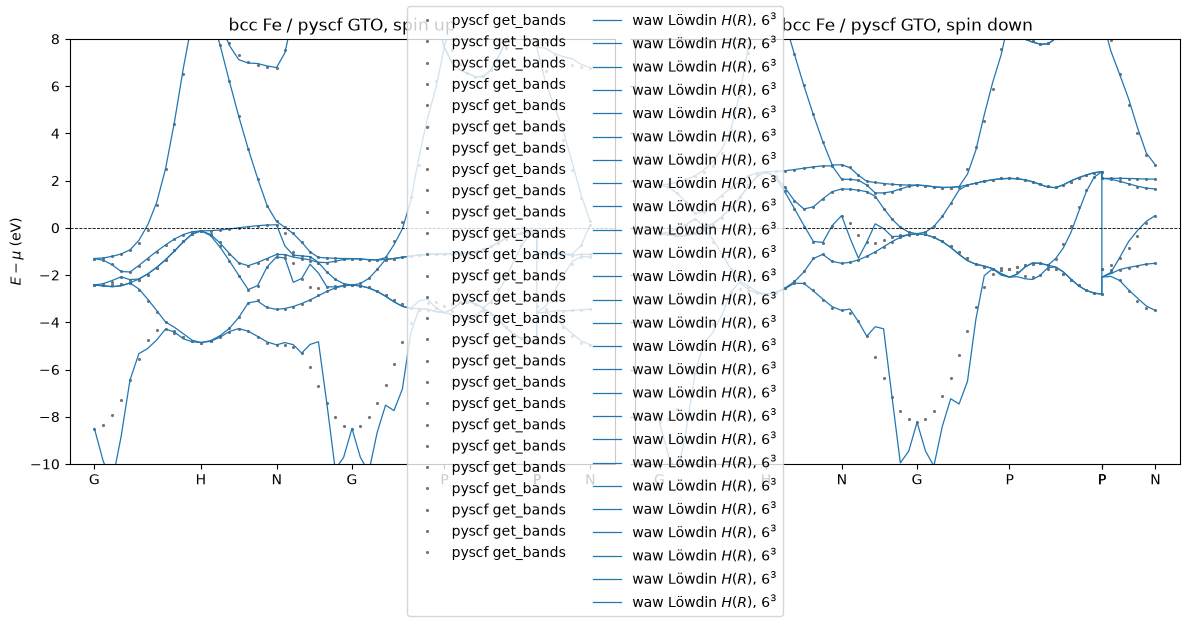

In [3]:
hr = {s: lowdin_hamiltonian_pyscf(fock[s], ovlp, kred, (NK, NK, NK), z['a_bohr'])
      for s in (0, 1)}

# on-mesh parity against the generalized eigenproblem F C = eps S C
for s in (0, 1):
    e_waw = band_eigensystem(hr[s], kred)[0]
    e_ref = np.array([geigh(fock[s][i], ovlp[i], eigvals_only=True)
                      for i in range(len(kred))])
    print(f'spin {s}: on-mesh max |dE| = '
          f'{np.abs(e_waw - e_ref).max() * HARTREE_TO_EV * 1e3:.2e} meV')

fe = bulk('Fe', 'bcc', a=2.8699)
cellv = fe.get_cell()[:]
if 'band_ref' in z.files:
    x, xt, xl = z['path_x'], z['path_xticks'], [str(v) for v in z['path_labels']]
    pk, bref = z['path_kpts'], z['band_ref']
else:
    bp = band_path(fe, npoints=120)
    x, xt, xl = bp.get_linear_kpoint_axis()
    pk, bref = bp.kpts, None

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, s in zip(axes, (0, 1)):
    e_w = band_eigensystem(hr[s], pk)[0] * HARTREE_TO_EV - MU * HARTREE_TO_EV
    if bref is not None:
        ax.plot(x, bref[s] * HARTREE_TO_EV - MU * HARTREE_TO_EV, '.', ms=2.5,
                color='0.45', label='pyscf get_bands' if s == 0 else None)
    ax.plot(x, e_w, '-', lw=0.9, color='C0',
            label=f'waw Löwdin $H(R)$, ${NK}^3$' if s == 0 else None)
    ax.set_xticks(xt); ax.set_xticklabels(xl); ax.set_ylim(-10, 8)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(f'bcc Fe / pyscf GTO, spin {"up" if s == 0 else "down"}')
axes[0].set_ylabel(r'$E - \mu$ (eV)')
fig.legend(loc='upper center', ncol=2)
plt.tight_layout(); plt.show()

### 3. The two LKAG formulations, isolated

Same $F$, same $S$, same $E_F$, same k-mesh, same $R$-list — the *only*
difference is whether the Green's function is built in the Löwdin-orthogonal
basis, $G = (z - S^{-1/2}FS^{-1/2})^{-1}$, or in the raw non-orthogonal one,
$G = (zS - F)^{-1}$ (with $\Delta_i$ taken from the corresponding on-site
block).  Both are legitimate definitions of an *effective* Heisenberg $J$; they
are simply not the same quantity, because the Löwdin transformation folds
tails of $S^{-1/2}$ into what counts as "site $i$".

In [4]:
D_BLOCK = [i for i, l in enumerate(labels) if ' 3d' in l]
Rbox = np.array([(i, j, k) for i in range(-3, 4) for j in range(-3, 4)
                 for k in range(-3, 4) if (i, j, k) != (0, 0, 0)])
RCUT = 6.0
Rl = Rbox[np.linalg.norm(Rbox @ cellv, axis=1) <= RCUT]

def shells(res, label):
    sh = {}
    for R in Rl:
        d = round(float(np.linalg.norm(np.array(R) @ cellv)), 3)
        sh.setdefault(d, []).append(res.J[(tuple(R), 0, 0)] * HARTREE_TO_EV * 1e3)
    cols = '  '.join(f'J{i+1}({d} Å)={np.mean(v):+7.3f}'
                     for i, (d, v) in enumerate(sorted(sh.items())[:3]))
    spread = max(np.ptp(v) for v in sh.values())
    print(f'{label:34s} m={res.magmoms[0]:+.3f}  {cols}   (max shell spread {spread:.4f} meV)')
    return sh

res_o_all = heisenberg_exchange(hr[0], hr[1], kred, MU, [list(range(NAO))], Rl, nz=100)
res_o_d = heisenberg_exchange(hr[0], hr[1], kred, MU, [D_BLOCK], Rl, nz=100)
res_n_all = heisenberg_exchange_nonortho(fock[0], fock[1], ovlp, kred, MU,
                                        [list(range(NAO))], Rl, nz=100)
res_n_d = heisenberg_exchange_nonortho(fock[0], fock[1], ovlp, kred, MU,
                                       [D_BLOCK], Rl, nz=100)
sh = {}
sh['o_all'] = shells(res_o_all, 'Löwdin ortho, all AOs')
sh['n_all'] = shells(res_n_all, 'non-orthogonal, all AOs')
sh['o_d'] = shells(res_o_d, f'Löwdin ortho, 3d only {D_BLOCK}')
sh['n_d'] = shells(res_n_d, 'non-orthogonal, 3d only')
print()
print('literature (Pajda et al., PRB 64, 174402): J1 = 19.5, J2 = 10.4 meV')
print('other waw backends, same semicore-pseudo family:')
print('  QE + Wannier (nb17, d block, 21^3): J1 =  7.1  J2 = 10.4')
print('  SIESTA NAO   (nb18, d block, 12^3): J1 =  7.7  J2 = 14.5')

Löwdin ortho, all AOs              m=+2.309  J1(2.485 Å)=+17.970  J2(2.87 Å)= +7.408  J3(4.059 Å)= +0.753   (max shell spread 0.0012 meV)
non-orthogonal, all AOs            m=+2.309  J1(2.485 Å)=+19.366  J2(2.87 Å)= +8.618  J3(4.059 Å)= +1.088   (max shell spread 0.0014 meV)
Löwdin ortho, 3d only [9, 10, 11, 12, 13] m=+2.429  J1(2.485 Å)=+13.630  J2(2.87 Å)= +7.473  J3(4.059 Å)= +1.125   (max shell spread 0.0010 meV)
non-orthogonal, 3d only            m=+2.455  J1(2.485 Å)=+19.793  J2(2.87 Å)= +9.085  J3(4.059 Å)= +1.124   (max shell spread 0.0011 meV)

literature (Pajda et al., PRB 64, 174402): J1 = 19.5, J2 = 10.4 meV
other waw backends, same semicore-pseudo family:
  QE + Wannier (nb17, d block, 21^3): J1 =  7.1  J2 = 10.4
  SIESTA NAO   (nb18, d block, 12^3): J1 =  7.7  J2 = 14.5


The spreads over symmetry-equivalent neighbours are $\lesssim$0.01 meV in
every variant: a Gaussian AO basis is symmetry-adapted for free, and the two
spin channels share it by construction, so none of notebook 17's
projection-gauge and frozen-window care is needed.

The formulation difference is real and sizeable — and it is *the same sign and
rough magnitude* as the Löwdin-vs-`siesta2J` gap measured across codes in
notebook 18, which is the point: that gap was **formulation**, not a bug in
either code.  Keep the comparison honest by always saying which $J$ definition
a number belongs to.

### 4. Magnons, and why the $R$-cutoff is the thing to watch

Notebook 17's lesson applies with full force to a metal: the spin stiffness
$D \sim \sum_{\mathbf R} J(\mathbf R)\,R^2$ is a delicate cancellation over an
oscillating (RKKY-like) tail, so a too-short $R$-cutoff can produce imaginary
long-wavelength magnons out of perfectly reasonable-looking shell $J$'s.  The
cutoff here is limited by the SCF mesh ($R$ lives on the Wigner–Seitz cell of
the k-mesh), which is the honest constraint of this demonstration.

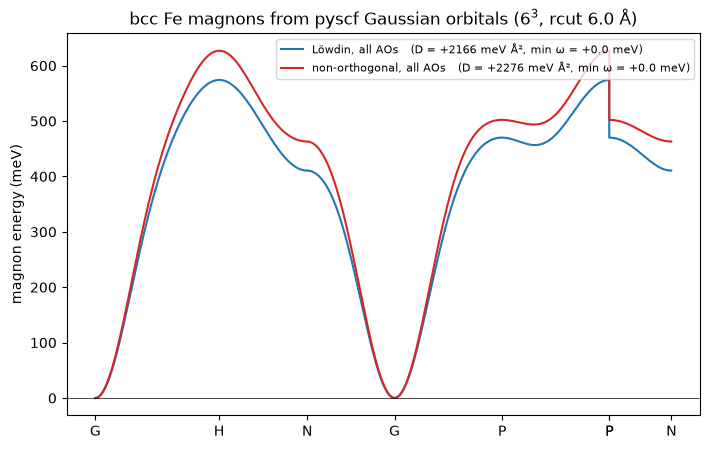

D > 0 and min ω >= 0 are the stability checks; a negative D means the
J(R) tail is truncated (raise the SCF k-mesh), not that Fe is unstable.


In [5]:
bp_m = band_path(fe, npoints=250)
xm, xmt, xml = bp_m.get_linear_kpoint_axis()
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for res, lab, c in ((res_o_all, 'Löwdin, all AOs', 'C0'),
                    (res_n_all, 'non-orthogonal, all AOs', 'C3')):
    D = sum(v * np.linalg.norm(np.array(R) @ cellv) ** 2
            for (R, i, j), v in res.J.items()) * HARTREE_TO_EV * 1e3
    w = magnon_bands(res.J, np.array([res.magmoms[0]]), bp_m.kpts) * HARTREE_TO_EV * 1e3
    ax.plot(xm, w[:, 0], color=c, label=f'{lab}   (D = {D:+.0f} meV Å², '
                                        f'min ω = {w.min():+.1f} meV)')
ax.set_xticks(xmt); ax.set_xticklabels(xml); ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('magnon energy (meV)'); ax.legend(fontsize=8)
ax.set_title(f'bcc Fe magnons from pyscf Gaussian orbitals (${NK}^3$, rcut {RCUT} Å)')
plt.tight_layout(); plt.show()
print('D > 0 and min ω >= 0 are the stability checks; a negative D means the')
print('J(R) tail is truncated (raise the SCF k-mesh), not that Fe is unstable.')

**Takeaway.**  Any code that can hand over $F(k)$ and $S(k)$ on a uniform mesh
is one Löwdin step away from the whole $H$-only half of waw.  Three backends
now do it, and the comparison is instructive rather than redundant:

| backend | localization | gauge care needed | symmetry of $J$ | Berry-class |
|---|---|---|---|---|
| QE + Wannier (nb 1–17) | MLWF, variational | windows, frozen manifolds, projection gauge | needs care (`sitesym`) | **yes** — full $AA_R$/$BB_R$/$CC_R$ |
| SIESTA NAO (nb 18) | atomic, fixed | none | free | no (no $\langle\phi|r|\phi'\rangle$) |
| pyscf GTO (this one) | atomic, fixed | none | free | not yet (`int1e_r` exists) |

The plane-wave/Wannier route remains the only one that reaches the
Berry-curvature observables, and it buys that with all the model-building
craft the other two skip.  For magnetism specifically, the atomic-basis routes
are simply easier and safer — and pyscf additionally lets both LKAG
formulations be compared with nothing else varying.